# Селектор материалов каменной кладки по СП 15.13330.2020

Блокнот показывает нормативные характеристики неармированной и сетчато-армированной кладки по СП 15.13330.2020 с Изменением № 1. Числовые значения таблиц 6.1–6.18 встроены в модуль sp15_materials.

Для сетчатого армирования используется формула (7.23):

$$R_{sk} = R + \frac{p \mu R_s \gamma_{cs}}{100} \le 2R,$$

а упругая характеристика и начальный модуль определяются как $E_0 = \alpha R_u$.


In [1]:
import sys
from pathlib import Path

project_dir = Path.cwd()
for p in [project_dir, project_dir.parent, project_dir.parent / "structural_materials"]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import ipywidgets as widgets

from sp15_materials import Masonry


In [2]:
# Интерактивная панель ввода. Расчетный вывод вынесен в следующую ячейку,
# поэтому nbconvert не зависит от жизненного цикла ipywidgets.Output.

def configure_control(control):
    control.style.description_width = "190px"
    control.layout = widgets.Layout(width="98%")
    return control

stone_type = configure_control(widgets.Dropdown(
    options={
        "Кирпич всех видов": "brick",
        "Керамические крупноформатные камни": "ceramic_large_block",
        "Ячеистобетонные блоки (автоклавного твердения)": "aerated_concrete",
    },
    value="brick",
    description="Вид кладки:",
))
stone_grade = configure_control(widgets.Dropdown(
    options=["M75", "M100", "M150", "M200"],
    value="M150",
    description="Марка камня:",
))
mortar_grade = configure_control(widgets.Dropdown(
    options=["M25", "M50", "M75", "M100", "M150"],
    value="M100",
    description="Раствор:",
))
area_m2 = configure_control(widgets.FloatText(value=1.0, description="Площадь сечения A, м²:"))
wire_diameter = configure_control(widgets.FloatSlider(value=4.0, min=3.0, max=8.0, step=0.5, description="Диаметр проволоки d, мм:"))
mesh_step = configure_control(widgets.IntSlider(value=50, min=30, max=120, step=5, description="Шаг ячейки сетки c, мм:"))
mesh_rows = configure_control(widgets.IntSlider(value=2, min=1, max=6, step=1, description="Интервал между сетками, рядов кладки:"))
masonry_box = widgets.VBox(
    [
        widgets.HTML("<b>Материал и сечение кладки</b>"),
        stone_type, stone_grade, mortar_grade, area_m2,
        widgets.HTML(
            "<b>Сетчатое армирование кладки</b><br>"
            "<small>d — диаметр проволоки; c — расстояние между проволоками сетки; "
            "интервал — число рядов кладки между соседними сетками.</small>"
        ),
        wire_diameter, mesh_step, mesh_rows,
    ],
    layout=widgets.Layout(border="1px solid #ddd", padding="10px"),
)
display(masonry_box)


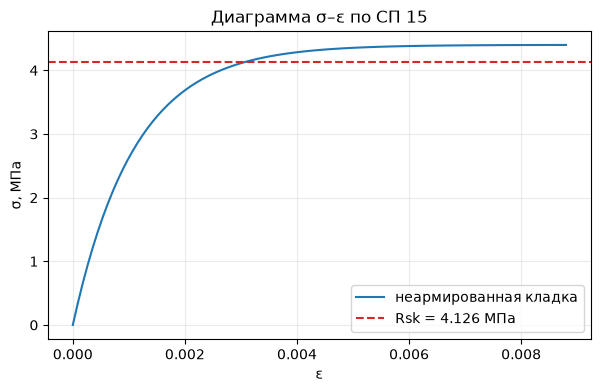

In [3]:
# Статический эталонный расчет: кирпич М150 / раствор М100.
masonry = Masonry("brick", "M150", "M100", area_m2=1.0)
reinforced = masonry.with_mesh_reinforcement(
    wire_diameter_mm=4,
    mesh_step_c_mm=50,
    mesh_rows_spacing=2,
    row_height_mm=65,
    rebar_class="B500",
    Rs=415.0,
    brick_type="single",
)

eps, sigma = masonry.get_diagram(n_points=100)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eps, sigma, label="неармированная кладка")
ax.axhline(reinforced.Rsk, color="tab:red", linestyle="--", label="Rsk = %.3f МПа" % reinforced.Rsk)
ax.set(xlabel="ε", ylabel="σ, МПа", title="Диаграмма σ–ε по СП 15")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


In [4]:
summary = r"""
| Характеристика | Неармированная | Армированная |
|---|---:|---:|
| $R$, $R_{sk}$, МПа | %.3f | %.3f |
| $R_u$, МПа | %.3f | — |
| $E_0$, МПа | %.1f | %.1f |
| $\mu$, %% | — | %.4f |
| Статус формулы (7.23) | — | %s |
""" % (
    masonry.R,
    reinforced.Rsk,
    masonry.Ru,
    masonry.E0,
    reinforced.E0_sk,
    reinforced.mu,
    "применима" if reinforced.is_applicable else "нужны опытные данные",
)
display(Markdown(summary))



| Характеристика | Неармированная | Армированная |
|---|---:|---:|
| $R$, $R_{sk}$, МПа | 2.200 | 4.126 |
| $R_u$, МПа | 4.400 | — |
| $E_0$, МПа | 4400.0 | 8251.1 |
| $\mu$, % | — | 0.3867 |
| Статус формулы (7.23) | — | применима |


In [5]:
# Практический пример: кирпичный простенок 380 × 640 мм.
wall_width_mm = 380
wall_height_mm = 640
wall_area_m2 = wall_width_mm * wall_height_mm / 1_000_000
wall = Masonry("brick", "M150", "M100", area_m2=wall_area_m2)
N_rd_kN = wall.R * wall_width_mm * wall_height_mm / 1000
display(Markdown(
    """### Простенок 380 × 640 мм

Площадь сечения $A = %.4f$ м², $R = %.3f$ МПа с учетом коэффициента по п. 6.14а.

Оценочная несущая способность при центральном сжатии: $N_{Rd} = R A = %.1f$ кН. Проверка внецентренного сжатия, гибкости и коэффициентов продольного изгиба выполняется отдельным расчетом по разделу 7 СП 15.
""" % (wall_area_m2, wall.R, N_rd_kN)
))


### Простенок 380 × 640 мм

Площадь сечения $A = 0.2432$ м², $R = 1.760$ МПа с учетом коэффициента по п. 6.14а.

Оценочная несущая способность при центральном сжатии: $N_{Rd} = R A = 428.0$ кН. Проверка внецентренного сжатия, гибкости и коэффициентов продольного изгиба выполняется отдельным расчетом по разделу 7 СП 15.
